# 04 - Flot optique Lucas-Kanade

Objectif : utiliser les points d?tect?s dans le meilleur masque obtenu ? l??tape 03. Nous n?utilisons pas le groundtruth pour initialiser les points.


## 1. Importation des biblioth?ques


In [1]:
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append("../")
from src.detection import extract_roi, preprocess_roi, segment_otsu, segment_adaptive, clean_mask, detect_features_in_mask, compare_masks
from src.optical_flow import compute_lucas_kanade, compute_mean_displacement
from src.visualization import draw_motion_vectors
plt.rcParams["figure.figsize"] = (12, 6)


## 2. Chargement de frame 0 et frame 1


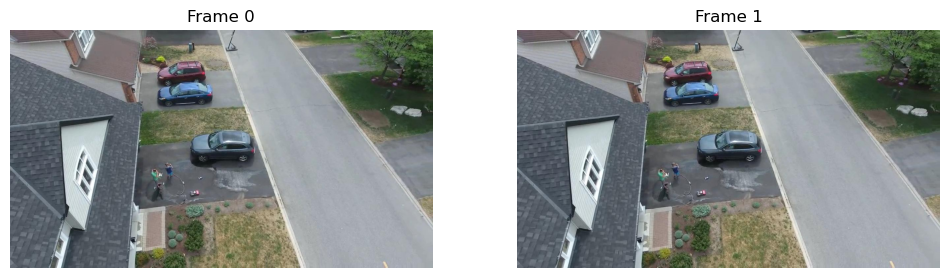

In [2]:
dataset_path = Path("../data/car/car-11")
img_path = dataset_path / "img"
results_path = Path("../results")
image_files = sorted([p for p in img_path.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
frame0_bgr = cv2.imread(str(image_files[0]))
frame1_bgr = cv2.imread(str(image_files[1]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(frame0_bgr, cv2.COLOR_BGR2RGB)); axes[0].set_title("Frame 0")
axes[1].imshow(cv2.cvtColor(frame1_bgr, cv2.COLOR_BGR2RGB)); axes[1].set_title("Frame 1")
for ax in axes: ax.axis("off")
plt.show()


## 3. Refaire ou charger l?initialisation

Nous chargeons `manual_bbox`, `best_mask` et `best_points`. Si le fichier n?existe pas, nous refaisons la segmentation de la premi?re frame.


In [3]:
init_path = results_path / "initialization_data.npz"
if init_path.exists():
    data = np.load(init_path, allow_pickle=True)
    manual_bbox = tuple(data["manual_bbox"].astype(int))
    best_mask = data["best_mask"]
    best_points = data["best_points"].astype(np.float32)
    best_method_name = str(data["best_method_name"])
else:
    manual_bbox = (535, 295, 220, 110)
    roi_bgr = extract_roi(frame0_bgr, manual_bbox)
    gray_roi = preprocess_roi(roi_bgr)
    mask_otsu = clean_mask(segment_otsu(gray_roi))
    mask_adaptive = clean_mask(segment_adaptive(gray_roi, block_size=31, C=5))
    points_otsu = detect_features_in_mask(gray_roi, mask_otsu)
    points_adaptive = detect_features_in_mask(gray_roi, mask_adaptive)
    best_method_name = compare_masks(mask_otsu, mask_adaptive, points_otsu, points_adaptive)
    best_mask, best_points = (mask_adaptive, points_adaptive) if best_method_name == "Adaptive" else (mask_otsu, points_otsu)
print("ROI manuelle :", manual_bbox)
print("M?thode choisie :", best_method_name)
print("Nombre de points :", 0 if best_points is None else len(best_points))


ROI manuelle : (np.int64(535), np.int64(295), np.int64(220), np.int64(110))
M?thode choisie : Otsu
Nombre de points : 80


## 4. Conversion des points ROI vers coordonn?es globales


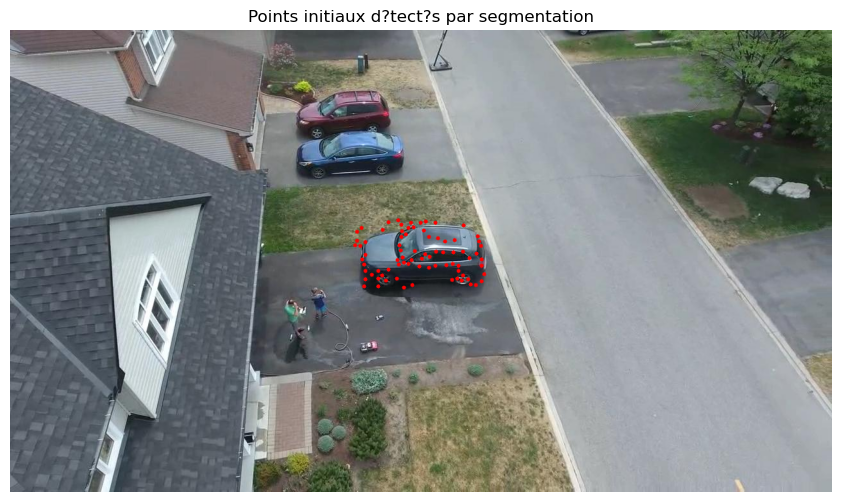

In [4]:
x_manual, y_manual, w_manual, h_manual = manual_bbox
points_global = best_points.copy().astype(np.float32)
points_global[:, 0, 0] += x_manual
points_global[:, 0, 1] += y_manual

img_points = frame0_bgr.copy()
for p in points_global.reshape(-1, 2):
    px, py = p.astype(int)
    cv2.circle(img_points, (px, py), 3, (0, 0, 255), -1)
plt.imshow(cv2.cvtColor(img_points, cv2.COLOR_BGR2RGB))
plt.title("Points initiaux d?tect?s par segmentation")
plt.axis("off")
plt.show()


## 5. Lucas-Kanade entre frame 0 et frame 1

Nous utilisons `winSize=(15,15)`, `maxLevel=2` et un crit?re de 10 it?rations ou epsilon `0.03`. Ces param?tres permettent de suivre des petits d?placements entre deux images proches.


In [5]:
def preprocess_full(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    return cv2.GaussianBlur(enhanced, (5, 5), 0)

prev_gray = preprocess_full(frame0_bgr)
next_gray = preprocess_full(frame1_bgr)
good_old, good_new = compute_lucas_kanade(prev_gray, next_gray, points_global)
print("Nombre de points suivis :", 0 if good_new is None else len(good_new))


Nombre de points suivis : 80


## 6. Visualisation des points et des vecteurs de mouvement


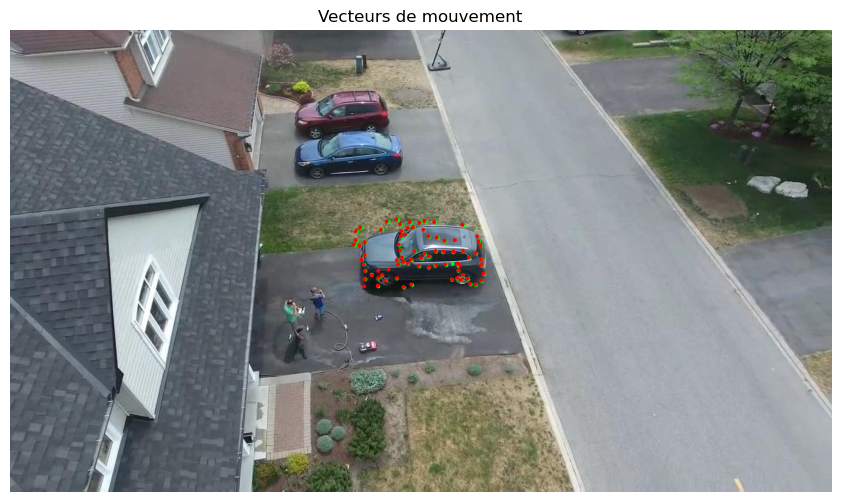

In [6]:
flow_image = draw_motion_vectors(frame1_bgr, good_old, good_new)
plt.imshow(cv2.cvtColor(flow_image, cv2.COLOR_BGR2RGB))
plt.title("Vecteurs de mouvement")
plt.axis("off")
plt.show()


## 7. D?placement moyen


In [7]:
mean_dx, mean_dy = compute_mean_displacement(good_old, good_new)
print(f"dx moyen : {mean_dx:.3f} pixels")
print(f"dy moyen : {mean_dy:.3f} pixels")


dx moyen : -0.338 pixels
dy moyen : -0.056 pixels


## 8. Conclusion

Les points suivis proviennent de notre segmentation, et non du groundtruth.
